# 08 · Branching processes

Each individual of a generation leaves a random number of offspring, independently: the Galton-Watson process
models family names, epidemics in their early phase, neutron chain reactions, cell lineages and the spread of a
viral post. Its fate is decided by the mean number of offspring m and computed with one tool - the probability
generating function, whose iterates give the extinction probabilities generation by generation.

**What you will learn**
- compute means and variances of generation sizes
- find extinction probabilities as fixed points of the pgf
- relate extinction to criticality and to offspring variability
- simulate branching processes efficiently

**Before you start:** notebook 05; probability generating functions  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import walks as wk
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Generation sizes

E[Z_n] simulated vs m^n: [(3.67, 3.71), (14.03, 13.79), (52.62, 51.19)]
Var[Z_n] simulated vs formula: [(34.3, 33.6), (654.0, 587.5)]


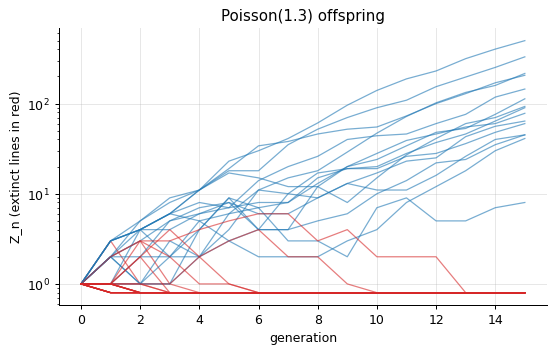

In [2]:
off = wk.pgf_poisson(1.3)
paths = np.array([wk.simulate_galton_watson(lambda k, r: r.poisson(1.3, k), 15, R(i)) for i in range(2000)])
mom = [wk.generation_moments(off, n) for n in range(16)]
print("E[Z_n] simulated vs m^n:", [(round(float(paths[:, n].mean()), 2), round(mom[n]["mean"], 2)) for n in (5, 10, 15)])
print("Var[Z_n] simulated vs formula:", [(round(float(paths[:, n].var()), 1), round(mom[n]["var"], 1)) for n in (5, 10)])
for k in range(40):
    plt.semilogy(np.maximum(paths[k], 0.8), color="C0" if paths[k, -1] else "C3", alpha=0.6, lw=1)
plt.xlabel("generation"); plt.ylabel("Z_n (extinct lines in red)"); plt.title("Poisson(1.3) offspring"); plt.show()

The mean grows like mⁿ, but the variance grows faster and individual lines either die early or grow
geometrically: the conditional law of Z_n/mⁿ given survival converges to a non-degenerate limit (the
Kesten-Stigum theorem). A population that has survived a few generations is very likely to survive for ever.

## Extinction: the smallest fixed point of the pgf

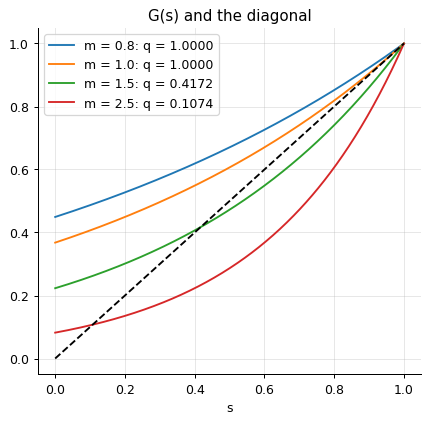

Poisson(1.5): q = 0.417188 after 65 iterations; P(extinct by generation n): [0.0, 0.2231, 0.3118, 0.3562, 0.3807, 0.395, 0.4035, 0.4087, 0.4119, 0.4139, 0.4151, 0.4159, 0.4164]


simulated P(extinct by generation 12): 0.4138


In [3]:
s = np.linspace(0, 1, 400)
fig, ax = plt.subplots(figsize=(5.5, 5))
for m in (0.8, 1.0, 1.5, 2.5):
    G = wk.pgf_poisson(m)["G"]
    q = wk.extinction_probability(wk.pgf_poisson(m))["q"]
    ax.plot(s, G(s), label=f"m = {m}: q = {q:.4f}")
ax.plot(s, s, "k--"); ax.legend(); ax.set_xlabel("s"); ax.set_title("G(s) and the diagonal"); plt.show()
q = wk.extinction_probability(wk.pgf_poisson(1.5))
qn = wk.extinction_by_generation(wk.pgf_poisson(1.5), 12)
print(f"Poisson(1.5): q = {q['q']:.6f} after {q['iterations']} iterations; P(extinct by generation n):", qn.round(4).tolist())
sim = np.mean([wk.simulate_galton_watson(lambda k, r: r.poisson(1.5, k), 12, R(1000 + i))[-1] == 0 for i in range(5000)])
print(f"simulated P(extinct by generation 12): {sim:.4f}")

Extinction by generation n has probability G∘G∘…∘G(0), and the limit q is the smallest root of G(s) = s in
[0, 1]. Since G is convex with G(1) = 1 and G′(1) = m, the root is 1 when m ≤ 1 and below 1 when m > 1 - the
threshold theorem. With Poisson offspring q = e^{m(q−1)}, the same equation as the final size of an epidemic
(notebook 11).

## Criticality and the variance of the offspring law

In [4]:
rows = []
for name, off in (("Poisson(1.2)", wk.pgf_poisson(1.2)), ("geometric, mean 1.2", wk.pgf_geometric(1 / 2.2)), ("0 or 2 children, mean 1.2", wk.pgf_discrete([0.4, 0.0, 0.6])),
                  ("1 or 2 children, mean 1.2", wk.pgf_discrete([0.0, 0.8, 0.2])), ("Poisson(1.0) - critical", wk.pgf_poisson(1.0))):
    r = wk.extinction_probability(off, tol=1e-12)
    rows.append((name, off["mean"], off["var"], r["q"], r["iterations"]))
print(pd.DataFrame(rows, columns=["offspring law", "mean", "variance", "extinction prob.", "iterations to 1e-12"]).to_string(index=False, float_format="%.4f"))
print(f"\nsubcritical Poisson(0.8): expected total progeny 1/(1 - m) = {wk.total_progeny_mean(wk.pgf_poisson(0.8)):.1f}")

            offspring law   mean  variance  extinction prob.  iterations to 1e-12
             Poisson(1.2) 1.2000    1.2000            0.6863                  127
      geometric, mean 1.2 1.2000    2.6400            0.8333                  132
0 or 2 children, mean 1.2 1.2000    0.9600            0.6667                  110
1 or 2 children, mean 1.2 1.2000    0.1600            0.0000                    1
  Poisson(1.0) - critical 1.0000    1.0000            1.0000              1000000

subcritical Poisson(0.8): expected total progeny 1/(1 - m) = 5.0


The same mean gives very different fates: the more variable the offspring law, the likelier extinction
(five geometric lines in six die out at m = 1.2, two in three Poisson lines, and none of those in which every
individual has at least one child). At criticality
extinction is certain but slow - the fixed-point iteration converges sublinearly and the expected total
progeny is infinite. Early-epidemic control works by pushing m below one, and superspreading (high variance)
helps outbreaks fizzle.

## Inside the algorithm: Newton's method for q = G(q)

In [5]:
G = lambda s: np.exp(1.5 * (s - 1)); dG = lambda s: 1.5 * np.exp(1.5 * (s - 1))
q = 0.0
for k in range(6):
    q = q - (G(q) - q) / (dG(q) - 1); print(k, f"{q:.15f}")
print("library (fixed-point iteration):", wk.extinction_probability(wk.pgf_poisson(1.5)))

0 0.335380375488521
1 0.410703143950854
2 0.417136783485020
3 0.417188352798996
4 0.417188356134189
5 0.417188356134189
library (fixed-point iteration): {'q': 0.4171883561341756, 'iterations': 65}


## Exercises
1. A new virus has offspring distribution negative binomial with mean R0 = 2.5 and dispersion k (variance R0 + R0^2/k). Compute the probability that a single introduction dies out for k = 0.1, 0.5, 1, 10 and infinity (Poisson).
2. For Poisson(1.0) offspring (critical), estimate P(Z_n > 0) for n = 10..1000 by iterating the pgf and show that it behaves like 2/(sigma^2 n) (Kolmogorov's estimate).
3. **Implement it yourself:** simulate the total progeny of a subcritical Poisson(0.8) process 10^4 times and compare its distribution with the Borel law P(T = n) = e^{-mn} (mn)^{n-1} / n!.